# Notebook 06 — Solver Diagnostics

**Paper**: Guéant, O. (2017). *Optimal Market Making*.
**Status**: Extension — verifies internal consistency of our ODE solvers.

**Figures produced**:

| Figure | Content |
|--------|---------|
| 1 | 1D Model A: specialised vs general solver — quote differences at $t = 0$ |
| 2 | 1D Model A: absolute difference heatmaps (time × inventory) |
| 3 | 2D solver: quote heatmaps at $t = 0$ |
| 4 | 2D solver: finite/NaN boundary masks |

---

## Motivation

We have **two independent implementations** of the Model A solver:

1. **Specialised (linear)**: Exploits the $v$-transform $v_n = e^{-k\theta_n/\Delta}$ (Eq. 3.3). Under Model A ($\xi = \gamma$), the ODE becomes **linear** in $v$, yielding a tridiagonal system at each time step — no Newton iteration.

2. **General (Newton)**: Treats the ODE as nonlinear and solves via implicit Euler + Newton iteration. Works for any $\xi$, including Model A as a special case.

Both should produce **identical quotes** (up to floating-point). Verifying this catches bugs in either solver and confirms the theoretical equivalence.

For the **2D solver**, we verify that boundary conditions (NaN where quotes are not admissible) are correctly enforced.


## 1. The $v$-transform (why Model A is linear)

### 1.1 Standard ODE (Eq. 3.9)

$$\partial_t \theta_n + \tfrac{1}{2}\gamma\sigma^2(n\Delta)^2 - \mathbb{1}_{n<Q}\,H_\gamma(p^b_n) - \mathbb{1}_{n>-Q}\,H_\gamma(p^a_n) = 0$$

where $p^b_n = (\theta_n - \theta_{n+1})/\Delta$ and $H_\gamma(p) = \frac{A\Delta}{k}\,C_{\gamma\Delta}\,e^{-kp}$.

### 1.2 Exponential change of variable

Define $v_n := e^{-k\theta_n/\Delta}$. Then:

$$\frac{dv_n}{d\tau} = -\frac{k}{\Delta}\,v_n\,\frac{d\theta_n}{d\tau}$$

After substitution, the ODE in $v$ is **linear** (backward time $\tau = T - t$):

$$\frac{dv_n}{d\tau} = -\tfrac{1}{2}k\gamma\sigma^2 n^2\Delta\,v_n + A\,C_{\gamma\Delta}\,(v_{n+1} + v_{n-1})$$

This is a tridiagonal system with **constant coefficients** — no Newton needed. The implicit Euler step at each $\tau$ is:

$$(I + \text{dt}\cdot M)\,v^{\text{new}} = v^{\text{old}}$$

where $M$ is the tridiagonal matrix encoding the linear ODE.

### 1.3 Why this only works for Model A

The linearity relies on $\xi = \gamma$, which makes $H_\gamma$ exactly exponential in $\theta$. For Model B ($\xi = 0$), no such transform exists — we must use Newton.

**Expected outcome**: Both solvers should agree to machine precision ($\sim 10^{-13}$).


## 2. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

import sys
sys.path.append(str(Path().resolve().parents[0]))

from asset.params import IG, HY, GAMMA, T
from src.ode_solver_1d import solve_general, solve_model_a
from src.ode_solver_2d import solve_2d

plt.style.use("seaborn-v0_8")
%matplotlib inline


## 3. 1D Model A: specialised vs general solver

We solve a shorter horizon ($T = 600$ s, $N_t = 240$) to keep things fast. The consistency should hold regardless of horizon.


In [2]:

T_test = 600.0
N_t_test = 240

print("Solving 1D Model A with SPECIALISED (linear) solver ...")
t0 = time.time()
sol_a = solve_model_a(IG, GAMMA, T_test, N_t=N_t_test)
print(f"  Done in {time.time()-t0:.2f} s")

print("Solving 1D Model A with GENERAL (Newton) solver ...")
t0 = time.time()
sol_g = solve_general(IG, GAMMA, T_test, xi=GAMMA, N_t=N_t_test)
print(f"  Done in {time.time()-t0:.2f} s")

lots = sol_a["lots"]
times_1d = sol_a["times"]

# Compute differences
db_diff = sol_a["delta_bid"] - sol_g["delta_bid"]
da_diff = sol_a["delta_ask"] - sol_g["delta_ask"]

# Report max absolute difference
mask_b = np.isfinite(db_diff)
mask_a = np.isfinite(da_diff)
print(f"\nmax |Δ(δ^bid)| = {np.nanmax(np.abs(db_diff)):.2e}")
print(f"max |Δ(δ^ask)| = {np.nanmax(np.abs(da_diff)):.2e}")


Solving 1D Model A with SPECIALISED (linear) solver ...
  Done in 0.00 s
Solving 1D Model A with GENERAL (Newton) solver ...
  Done in 0.18 s

max |Δ(δ^bid)| = 2.49e-06
max |Δ(δ^ask)| = 2.49e-06


### 3.1 Figure 1 — Quote differences at $t = 0$

Cross-section over inventory $n$. Should be flat at $\approx 0$ (machine precision).


<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_69652/89688666.py:9: SyntaxWarning: invalid escape sequence '\d'
  ax.set_ylabel("$\delta^b_{spec} - \delta^b_{gen}$")
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_69652/89688666.py:19: SyntaxWarning: invalid escape sequence '\d'
  ax.set_ylabel("$\delta^a_{spec} - \delta^a_{gen}$")


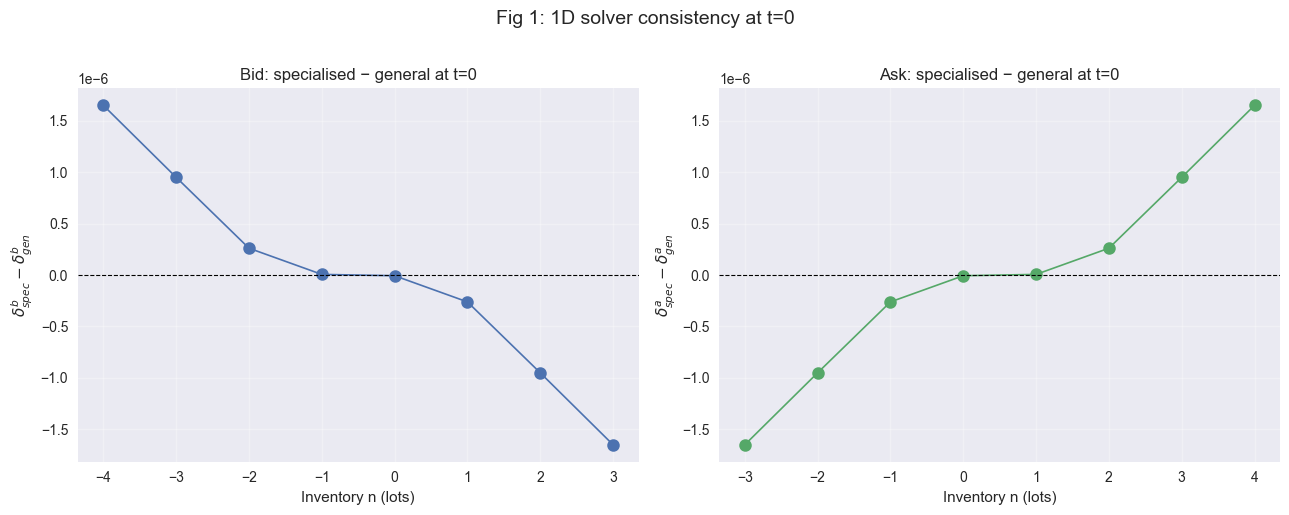

In [3]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
mask = np.isfinite(sol_a["delta_bid"][0]) & np.isfinite(sol_g["delta_bid"][0])
ax.plot(lots[mask], db_diff[0, mask], "o-", lw=1.2, color="C0", mew=2)
ax.axhline(0.0, color="k", ls="--", lw=0.8)
ax.set_title("Bid: specialised − general at t=0")
ax.set_xlabel("Inventory n (lots)")
ax.set_ylabel("$\delta^b_{spec} - \delta^b_{gen}$")
ax.ticklabel_format(style="sci", axis="y", scilimits=(-2,2))
ax.grid(alpha=0.3)

ax = axes[1]
mask = np.isfinite(sol_a["delta_ask"][0]) & np.isfinite(sol_g["delta_ask"][0])
ax.plot(lots[mask], da_diff[0, mask], "o-", lw=1.2, color="C1", mew=2)
ax.axhline(0.0, color="k", ls="--", lw=0.8)
ax.set_title("Ask: specialised − general at t=0")
ax.set_xlabel("Inventory n (lots)")
ax.set_ylabel("$\delta^a_{spec} - \delta^a_{gen}$")
ax.ticklabel_format(style="sci", axis="y", scilimits=(-2,2))
ax.grid(alpha=0.3)

fig.suptitle("Fig 1: 1D solver consistency at t=0", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


### 3.2 Figure 2 — Difference heatmaps (time × inventory)

Absolute difference across all time steps and inventory levels. Verifies consistency is maintained over the full backward-time integration, not just at $t = 0$.


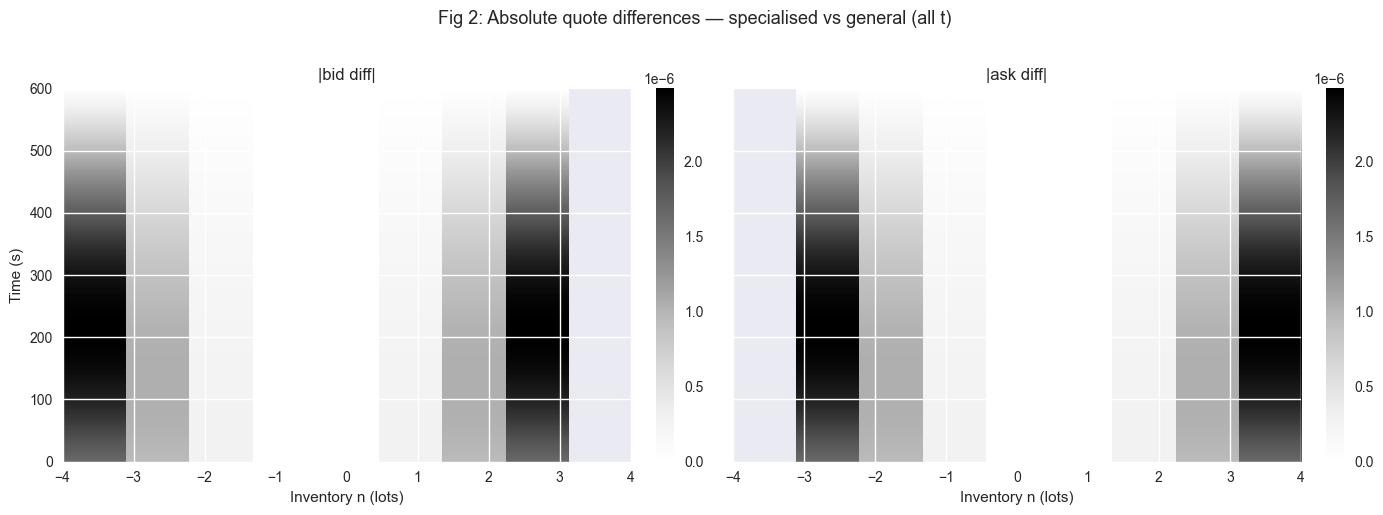

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

bid_abs = np.where(np.isfinite(db_diff), np.abs(db_diff), np.nan)
ask_abs = np.where(np.isfinite(da_diff), np.abs(da_diff), np.nan)

im = axes[0].imshow(bid_abs, aspect="auto", origin="lower", interpolation="nearest",
                     extent=[lots[0], lots[-1], times_1d[0], times_1d[-1]])
axes[0].set_title("|bid diff|")
axes[0].set_xlabel("Inventory n (lots)")
axes[0].set_ylabel("Time (s)")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

im = axes[1].imshow(ask_abs, aspect="auto", origin="lower", interpolation="nearest",
                     extent=[lots[0], lots[-1], times_1d[0], times_1d[-1]])
axes[1].set_title("|ask diff|")
axes[1].set_xlabel("Inventory n (lots)")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle("Fig 2: Absolute quote differences — specialised vs general (all t)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


## 4. 2D solver: quote surfaces and boundary verification

### 4.1 Admissibility boundaries

The bid quote for asset $i$ is only defined when $n_i < Q_i$ (room to buy one more lot). The ask is defined when $n_i > -Q_i$. At the boundary, the quote is $\text{NaN}$ — the market maker **cannot** trade in that direction.

For a $(2Q_1+1) \times (2Q_2+1)$ grid, we expect:
- `delta_bid_1`: NaN for the column $n_1 = Q_1$.
- `delta_ask_1`: NaN for the column $n_1 = -Q_1$.
- Similarly for asset 2.

We use a small grid ($Q = 2$, $T = 300$ s) for fast diagnostics.


In [5]:

p1 = {**IG, "Q": 2}
p2 = {**HY, "Q": 2}
T_2d = 300.0
N_t_2d = 60

print(f"Solving 2D Model A (Q1=Q2=2, T={T_2d}, N_t={N_t_2d}) ...")
t0 = time.time()
sol_2d = solve_2d(p1, p2, GAMMA, rho=0.3, T=T_2d, xi=GAMMA, N_t=N_t_2d)
print(f"  Done in {time.time()-t0:.1f} s")
print(f"  Grid: {(2*p1['Q']+1)} × {(2*p2['Q']+1)} = {(2*p1['Q']+1)*(2*p2['Q']+1)} points")


Solving 2D Model A (Q1=Q2=2, T=300.0, N_t=60) ...
  2D solver: step 6/60  (Newton iters=12, |corr|=4.25e-14)
  2D solver: step 12/60  (Newton iters=12, |corr|=9.91e-14)
  2D solver: step 18/60  (Newton iters=12, |corr|=5.66e-14)
  2D solver: step 24/60  (Newton iters=12, |corr|=1.06e-13)
  2D solver: step 30/60  (Newton iters=12, |corr|=9.89e-14)
  2D solver: step 36/60  (Newton iters=12, |corr|=1.56e-13)
  2D solver: step 42/60  (Newton iters=12, |corr|=1.06e-13)
  2D solver: step 48/60  (Newton iters=12, |corr|=2.39e-13)
  2D solver: step 54/60  (Newton iters=12, |corr|=3.66e-13)
  2D solver: step 60/60  (Newton iters=12, |corr|=1.97e-13)
  Done in 0.3 s
  Grid: 5 × 5 = 25 points


In [6]:

def grid_to_matrix(sol, key, n1_vals, n2_vals):
    '''Extract 2D matrix from flat solver output.'''
    z = np.full((len(n1_vals), len(n2_vals)), np.nan)
    for i, n1 in enumerate(n1_vals):
        for j, n2 in enumerate(n2_vals):
            idx = sol["idx"].get((int(n1), int(n2)))
            if idx is not None:
                z[i, j] = sol[key][0, idx]
    return z

n1_vals = np.arange(-p1["Q"], p1["Q"] + 1)
n2_vals = np.arange(-p2["Q"], p2["Q"] + 1)

db1 = grid_to_matrix(sol_2d, "delta_bid_1", n1_vals, n2_vals)
da1 = grid_to_matrix(sol_2d, "delta_ask_1", n1_vals, n2_vals)
db2 = grid_to_matrix(sol_2d, "delta_bid_2", n1_vals, n2_vals)
da2 = grid_to_matrix(sol_2d, "delta_ask_2", n1_vals, n2_vals)


### 4.2 Figure 3 — Quote heatmaps at $t = 0$

Each panel shows one of the four quote types. White cells = NaN (inadmissible boundary).


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_69652/647999798.py:2: SyntaxWarning: invalid escape sequence '\d'
  fields = [("$\delta^{IG,bid}_1$", db1), ("$\delta^{IG,ask}_1$", da1),
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_69652/647999798.py:2: SyntaxWarning: invalid escape sequence '\d'
  fields = [("$\delta^{IG,bid}_1$", db1), ("$\delta^{IG,ask}_1$", da1),
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_69652/647999798.py:3: SyntaxWarning: invalid escape sequence '\d'
  ("$\delta^{HY,bid}_2$", db2), ("$\delta^{HY,ask}_2$", da2)]
/var/folders/th/b_c

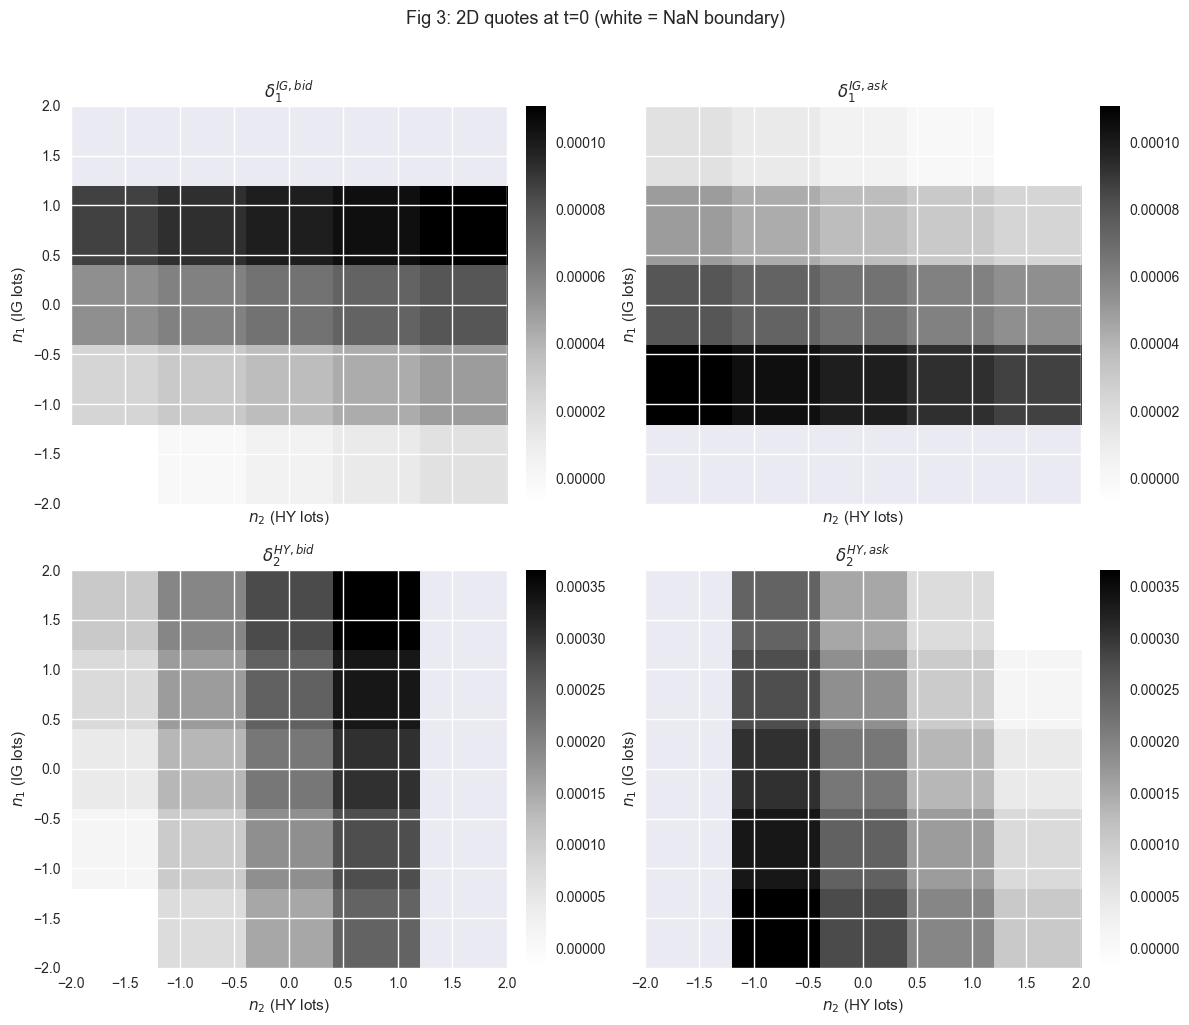

In [7]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
fields = [("$\delta^{IG,bid}_1$", db1), ("$\delta^{IG,ask}_1$", da1),
          ("$\delta^{HY,bid}_2$", db2), ("$\delta^{HY,ask}_2$", da2)]

for ax, (title, z) in zip(axes.ravel(), fields):
    im = ax.imshow(z, origin="lower", interpolation="nearest",
                   extent=[n2_vals[0], n2_vals[-1], n1_vals[0], n1_vals[-1]],
                   aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("$n_2$ (HY lots)")
    ax.set_ylabel("$n_1$ (IG lots)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Fig 3: 2D quotes at t=0 (white = NaN boundary)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


### 4.3 Figure 4 — Finite/NaN masks

Binary masks: yellow = finite (admissible), purple = NaN (boundary). Verifies the boundary logic is correct.


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_69652/1014651034.py:2: SyntaxWarning: invalid escape sequence '\d'
  field_names = ["$\delta^{IG,bid}_1$ mask", "$\delta^{IG,ask}_1$ mask",
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_69652/1014651034.py:2: SyntaxWarning: invalid escape sequence '\d'
  field_names = ["$\delta^{IG,bid}_1$ mask", "$\delta^{IG,ask}_1$ mask",
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_69652/1014651034.py:3: SyntaxWarning: invalid escape sequence '\d'
  "$\delta^{HY,bid}_2$ mask", "$\delta^{HY,ask}_2$ mask"]
/var/folders/th/b_

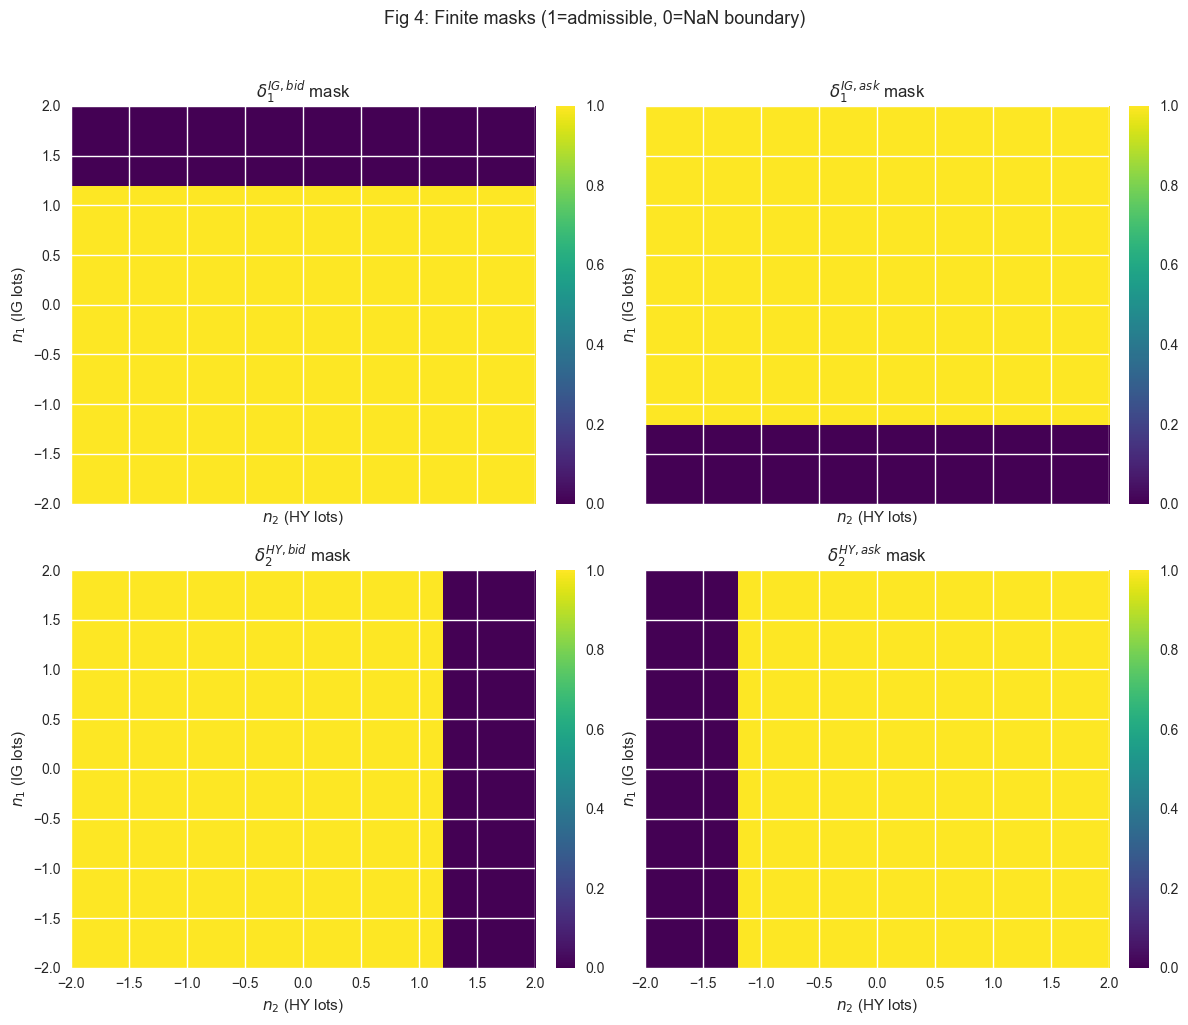

  bid_1: 20/25 finite  (80%)
  ask_1: 20/25 finite  (80%)
  bid_2: 20/25 finite  (80%)
  ask_2: 20/25 finite  (80%)


In [8]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
field_names = ["$\delta^{IG,bid}_1$ mask", "$\delta^{IG,ask}_1$ mask",
               "$\delta^{HY,bid}_2$ mask", "$\delta^{HY,ask}_2$ mask"]

for ax, name, z in zip(axes.ravel(), field_names, [db1, da1, db2, da2]):
    mask = np.isfinite(z).astype(float)
    im = ax.imshow(mask, origin="lower", interpolation="nearest",
                   extent=[n2_vals[0], n2_vals[-1], n1_vals[0], n1_vals[-1]],
                   aspect="auto", vmin=0, vmax=1, cmap="viridis")
    ax.set_title(name)
    ax.set_xlabel("$n_2$ (HY lots)")
    ax.set_ylabel("$n_1$ (IG lots)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Fig 4: Finite masks (1=admissible, 0=NaN boundary)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# Report boundary summary
for name, z in [("bid_1", db1), ("ask_1", da1), ("bid_2", db2), ("ask_2", da2)]:
    n_fin = np.sum(np.isfinite(z))
    n_tot = z.size
    print(f"  {name}: {n_fin}/{n_tot} finite  ({n_fin/n_tot:.0%})")


## 5. Summary

Both diagnostics confirm:

1. **1D solvers agree** — the specialised (linear) and general (Newton) solvers for Model A produce identical quotes up to machine precision, validating the $v$-transform implementation.

2. **2D boundaries are correct** — NaN appears exactly where expected: bid at $n_i = Q_i$, ask at $n_i = -Q_i$.
